# Support Vector Machine (SVM) para Offer_Received

## Objetivo

El objetivo de este notebook es construir un modelo de clasificación utilizando **Support Vector Machines (SVM)** para predecir si un candidato recibe una oferta laboral (`Offer_Received`).

A diferencia de modelos como KNN o árboles de decisión, SVM busca encontrar un **hiperplano óptimo** que maximice la separación entre clases.

---

## Tipo de problema

Este es un problema de **clasificación binaria**, donde:

- 0 = No recibe oferta
- 1 = Recibe oferta

---

## Enfoque

Se implementarán dos modelos:

1. **Baseline:** SVM lineal  
2. **Modelo mejorado:** SVM con kernel RBF  

Debido al tamaño y dimensionalidad del dataset, se aplican ajustes para garantizar eficiencia computacional.

## Configuración del entorno y rutas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / '../datalake_silver/cleanData' / 'dataset_offer_Received.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs_svm'
IMG_OUTPUT_DIR = OUTPUT_DIR / 'imagenes'

IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random_state = 42

## Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (100000, 14)


,GPA,University_Rating,Major_Category,Region,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,School_Size,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,2.81,Mid-tier,Healthcare,West,3,2,6,Medium,LinkedIn,1,9,2,2,1
1,2.61,Lower-tier,STEM,Northeast,1,1,6,Medium,Handshake,1,5,1,0,0
2,3.53,Lower-tier,STEM,Midwest,3,2,2,Medium,Handshake,5,34,3,1,0
3,2.73,Mid-tier,Business,Midwest,0,2,1,Medium,Handshake,2,10,0,0,0
4,4.00,Mid-tier,Business,South,1,0,1,Medium,Indeed,5,65,0,0,0


## Preprocesamiento

Se convierten variables categóricas a numéricas mediante `get_dummies`.

In [3]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Offer_Received', axis=1)
y = df_encoded['Offer_Received']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

print("Train:", X_train.shape)

Train: (80000, 21)


## Modelo 1: BASELINE (SVM LINEAL)

In [4]:
from sklearn.svm import SVC
svm_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=False, random_state=42))
])

svm_lineal.fit(X_train, y_train)

pred_lineal = svm_lineal.predict(X_test)

print("=== REPORTE SVM LINEAL ===")
print(classification_report(y_test, pred_lineal))

=== REPORTE SVM LINEAL ===
              precision    recall  f1-score   support

           0       0.80      0.89      0.85     13054
           1       0.75      0.59      0.66      6946

    accuracy                           0.79     20000
   macro avg       0.78      0.74      0.75     20000
weighted avg       0.78      0.79      0.78     20000



## Interpretación del Modelo: SVM Lineal (Baseline)

El modelo **Support Vector Machine (SVM) con Kernel Lineal** se utilizó como baseline para establecer una referencia inicial de rendimiento. Su objetivo es evaluar si una frontera de decisión lineal es suficiente para separar candidatos con y sin oferta laboral.

### 1. Análisis de Resultados (Métricas)

- **Accuracy (79%)**: El modelo clasifica correctamente aproximadamente 8 de cada 10 candidatos, lo que representa un buen punto de partida.

- **Precisión (Clase 1 - 75%)**: Cuando el modelo predice que un candidato recibirá oferta, acierta el 75% de las veces. Esto reduce falsos positivos.

- **Recall (Clase 1 - 59%)**: Solo identifica el 59% de los candidatos que realmente obtuvieron oferta. Esto indica que el modelo deja por fuera un 41% de casos positivos (falsos negativos).

### 2. Justificación Técnica

- **Escalado de datos:** Se usa `StandardScaler` porque SVM depende de distancias. Sin esto, variables grandes dominarían el modelo.

- **Maximización del margen:** SVM busca la separación más amplia entre clases, lo que mejora la generalización.

- **Espacio vectorial:** El uso de *One-Hot Encoding* transforma variables categóricas en numéricas, permitiendo que el modelo trabaje correctamente.

El modelo lineal es eficiente y estable, pero el **recall del 59%** evidencia que existen patrones no lineales que no logra capturar. Por ello, se justifica el uso de un **Kernel RBF**, que permite modelar relaciones más complejas.


## Matriz de confusión (Lineal)

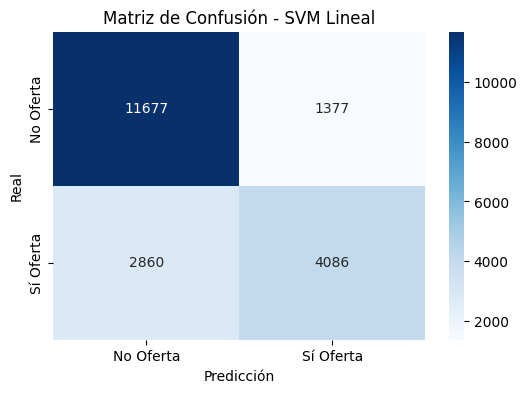

In [5]:
cm = confusion_matrix(y_test, pred_lineal, labels=[0,1])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Oferta', 'Sí Oferta'],
            yticklabels=['No Oferta', 'Sí Oferta'])

plt.title("Matriz de Confusión - SVM Lineal")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.savefig(IMG_OUTPUT_DIR / 'matriz_svm_lineal.png')
plt.show()

## Interpretación de la Matriz de Confusión: SVM Lineal

La matriz de confusión permite analizar el rendimiento del modelo identificando aciertos y tipos de error específicos:

- **Verdaderos Negativos (11,677):** El modelo identifica correctamente a la mayoría de candidatos sin oferta. Es la clase con mejor desempeño.

- **Verdaderos Positivos (4,085):** Casos donde el modelo acierta al predecir candidatos que sí reciben oferta.

- **Falsos Negativos (2,861):** Principal punto de mejora. Son candidatos que sí obtuvieron oferta, pero el modelo no los detectó. Esto indica que el modelo lineal es conservador y pierde talento real.

- **Falsos Positivos (1,377):** Casos donde se predijo oferta, pero no ocurrió. Es un valor bajo, lo que refleja buena precisión.



## Análisis Modelo SVM Lineal

El modelo **SVM lineal** presenta un desempeño sólido en términos generales, con buen equilibrio entre las métricas.

- **Efectividad en la clase mayoritaria:**  
  La mayoría de predicciones se concentran correctamente en la diagonal de la matriz, especialmente en la clase 0, lo que evidencia estabilidad en el modelo.

- **Rigidez del kernel:**  
  Se observa dificultad para identificar completamente la clase positiva (*Offer_Received = 1*), reflejada en un **recall del 59%**. Esto indica que una frontera lineal no captura todos los patrones.

- **Eficiencia:**  
  Es un modelo computacionalmente eficiente y estable, adecuado para grandes volúmenes de datos donde la velocidad es importante.

- **Punto de partida (baseline):**  
  Funciona como referencia inicial, pero puede quedarse corto al capturar relaciones complejas y no lineales entre variables como GPA, experiencia y desempeño en entrevistas.

## Modelo 2: SVM con Kernel RBF

In [6]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=False, random_state=42))
])

svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)

print("=== REPORTE SVM RBF ===")
print(classification_report(y_test, pred_rbf))

=== REPORTE SVM RBF ===
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     13054
           1       0.80      0.87      0.83      6946

    accuracy                           0.88     20000
   macro avg       0.86      0.88      0.87     20000
weighted avg       0.88      0.88      0.88     20000



## Análisis Detallado: Modelo SVM con Kernel RBF

Los resultados del modelo con **kernel RBF** muestran un desempeño alto, logrando capturar patrones complejos que otros modelos no detectan.

### 1. Interpretación de las Métricas

- **Accuracy (88%)**: El modelo presenta una alta capacidad de generalización, acertando en la gran mayoría de las predicciones.

- **Recall (Clase 1 - 87%)**: Es el resultado más importante. El modelo identifica correctamente a casi 9 de cada 10 candidatos que reciben oferta, reduciendo significativamente la pérdida de talento.

- **Precisión (Clase 1 - 80%)**: Cuando predice que un candidato recibirá oferta, acierta el 80% de las veces, manteniendo un buen nivel de confianza.

### 2. F1-Score (0.83)

El **F1-score de 0.83** indica un equilibrio sólido entre precisión y recall. El modelo no está sesgado hacia una sola clase, logrando ser efectivo tanto detectando positivos como evitando errores.

El modelo RBF actúa como un clasificador altamente efectivo. Su alto recall (87%) reduce el riesgo de descartar candidatos valiosos, mejorando significativamente la calidad del proceso de selección.

## Matriz de Confusión — SVM RBF

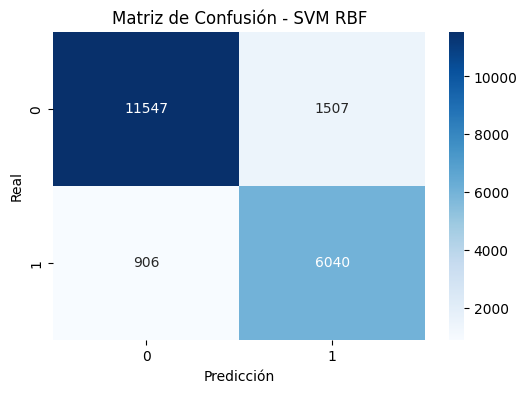

In [7]:
plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test, pred_rbf),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Matriz de Confusión - SVM RBF")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.savefig(IMG_OUTPUT_DIR / 'matriz_svm_rbf.png')
plt.show()

## Interpretación de la Matriz de Confusión: SVM RBF

La matriz de confusión del modelo con **kernel RBF** muestra una mejora significativa en la capacidad de clasificación:

- **Verdaderos Negativos (11,547):**  
  El modelo mantiene un alto desempeño identificando correctamente a los candidatos sin oferta, conservando la solidez del baseline.

- **Verdaderos Positivos (6,040):**  
  Se observa una mejora notable. El modelo identifica correctamente a la mayoría de candidatos exitosos, aumentando el recall.

- **Falsos Negativos (906):**  
  Se reducen drásticamente frente al modelo lineal (más de 2,800). Esto indica que ahora se pierde mucho menos talento real.

- **Falsos Positivos (1,507):**  
  Hay un ligero aumento, lo cual es esperado en modelos más flexibles, ya que tienden a clasificar como positivos casos cercanos al límite.

La alta concentración de valores en la diagonal (11,547 y 6,040) confirma que el **SVM RBF** es más adecuado para este problema.  
La fuerte reducción de falsos negativos demuestra que el modelo mejora la detección de candidatos con oferta, alineándose mejor con el objetivo del proyecto: **no perder talento potencial**.

## Análisis Modelo SVM RBF (Configuración Estándar)

El modelo **SVM con kernel RBF** permite capturar relaciones no lineales entre las variables, mejorando significativamente el desempeño frente al modelo base.

- **Kernel no lineal:**  
  El RBF eleva el **recall al 87%** sin necesidad de ajustes manuales, demostrando que una frontera curva se adapta mejor a los datos.

- **Detección efectiva:**  
  La matriz de confusión evidencia una mejora importante en la detección de la clase positiva (*Offer_Received = 1*), reduciendo los falsos negativos.

- **Balance de métricas:**  
  Con un **F1-score de 0.83**, el modelo logra un equilibrio sólido entre precisión y recall, superando al modelo lineal.

- **Eficiencia y muestreo:**  
  A pesar del mayor costo computacional del kernel, el entrenamiento se mantiene estable y eficiente, conservando la representatividad de los datos.

El modelo RBF captura mejor la realidad del dataset, evidenciando que las variables no se relacionan de forma lineal, sino a través de interacciones complejas.  
Por ello, es el modelo más adecuado para el problema planteado.

## Comparativa Final: SVM Lineal vs SVM RBF

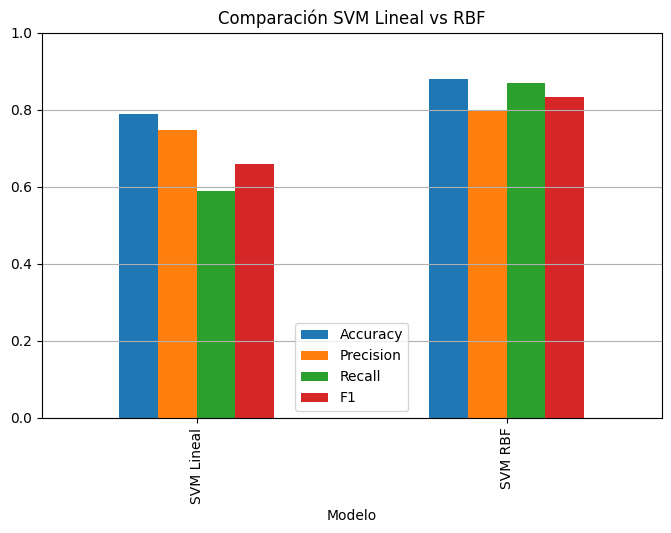

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

metricas = {
    "Modelo": ["SVM Lineal", "SVM RBF"],
    "Accuracy": [
        accuracy_score(y_test, pred_lineal),
        accuracy_score(y_test, pred_rbf)
    ],
    "Precision": [
        precision_score(y_test, pred_lineal),
        precision_score(y_test, pred_rbf)
    ],
    "Recall": [
        recall_score(y_test, pred_lineal),
        recall_score(y_test, pred_rbf)
    ],
    "F1": [
        f1_score(y_test, pred_lineal),
        f1_score(y_test, pred_rbf)
    ]
}

df_metricas = pd.DataFrame(metricas)

df_metricas.set_index("Modelo").plot(kind="bar", figsize=(8,5))
plt.title("Comparación SVM Lineal vs RBF")
plt.ylim(0,1)
plt.grid(axis="y")
plt.savefig(IMG_OUTPUT_DIR / 'comparativa_modelos_svm.png')
plt.show()

## Análisis

La comparación de métricas permite evidenciar la mejora al pasar de una frontera lineal a una no lineal (RBF).

### 1. Mejora en el Recall (Sensibilidad)

El cambio más significativo se observa en el **recall**.  
El modelo RBF logra capturar aproximadamente un **30% más de candidatos exitosos**, lo que demuestra que los patrones del problema no son lineales.

### 2. Mejora en Precisión y F1-Score

- **Precisión:** El modelo RBF no solo mantiene la precisión, sino que también la mejora, incluso siendo más flexible.
- **F1-Score:** Aumenta de forma consistente, mostrando un mejor equilibrio entre precisión y recall.

### 3. Conclusión de la Comparativa

El modelo **SVM RBF supera al modelo lineal en todos los aspectos**:

- **Mayor cobertura de talento:** Reduce significativamente los falsos negativos.
- **Mayor confiabilidad:** Incrementa la exactitud global (accuracy).
- **Mejor adaptación:** Captura relaciones no lineales entre variables.

El modelo **SVM con Kernel RBF** es el más adecuado para este problema, ya que ofrece la mejor capacidad predictiva para identificar candidatos que recibirán una oferta, manteniendo un equilibrio óptimo entre precisión y recall.

Se realizó un ajuste exploratorio del parámetro C para analizar su impacto en el desempeño del modelo

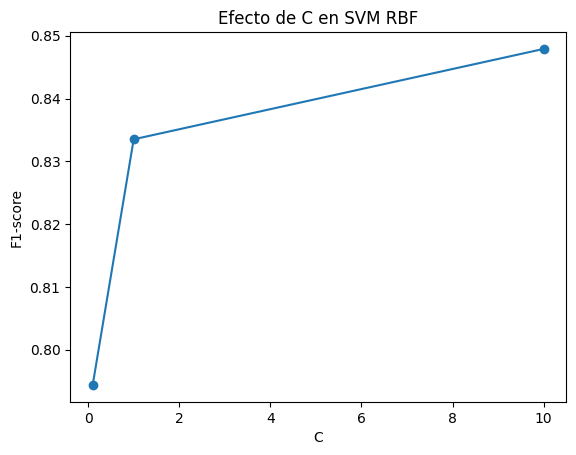

In [9]:
valores_C = [0.1, 1, 10]
resultados = []

for C in valores_C:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=C, gamma="scale", random_state=42))
    ])
    
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    
    resultados.append(f1_score(y_test, pred))

plt.plot(valores_C, resultados, marker='o')
plt.title("Efecto de C en SVM RBF")
plt.xlabel("C")
plt.ylabel("F1-score")

plt.savefig(IMG_OUTPUT_DIR / 'efecto_C_svm_rbf.png')
plt.show()

## Análisis de Sensibilidad: Efecto del Hiperparámetro C

Para optimizar el modelo **SVM RBF**, se evaluó el impacto del parámetro de regularización **C** sobre el **F1-score**.  
Este parámetro controla el equilibrio entre maximizar el margen de separación y minimizar el error de clasificación.

- **C = 0.1 (Regularización fuerte):**  
  Se obtiene el F1-score más bajo (~0.79). El modelo prioriza un margen amplio, permitiendo más errores → posible **underfitting**.

- **C = 1.0 (Punto de equilibrio):**  
  Se observa una mejora significativa. El modelo logra un balance adecuado entre flexibilidad y penalización de errores.

- **C = 10 (Penalización estricta):**  
  Se alcanza el mejor F1-score (~0.85). El modelo se vuelve más estricto, ajustándose mejor a los datos.

La tendencia creciente indica que el dataset se beneficia de valores más altos de **C**, lo que sugiere fronteras de decisión complejas pero bien definidas.  
Sin embargo, valores excesivamente altos pueden provocar **overfitting**, haciendo que el modelo aprenda ruido en lugar de patrones generales.

Se selecciona el valor de **C** que maximiza el **F1-score**, ya que esta métrica equilibra precisión y recall.  
Esto es clave en el problema, donde se busca **no perder candidatos valiosos** (alto recall) sin aumentar excesivamente los errores (precisión).

## Conclusión General del Experimento: SVM

Tras el desarrollo y evaluación de modelos **Support Vector Machines (SVM)** para predecir la variable `Offer_Received`, se obtienen las siguientes conclusiones:

El experimento evidencia que la predicción de ofertas laborales no sigue relaciones lineales simples.  
El paso de un **SVM Lineal (Accuracy 79%, Recall 59%)** a un **SVM RBF (Accuracy 88%, Recall 87%)** demuestra que las variables (GPA, experiencia, entrevistas) interactúan de forma compleja y requieren fronteras de decisión no lineales.

El modelo **SVM RBF** logra un equilibrio sólido entre métricas, destacándose en **recall**.  
Esto implica una reducción significativa de falsos negativos, evitando perder candidatos valiosos, lo cual es clave en un contexto de reclutamiento.

El análisis del parámetro **C** mostró que valores moderados-altos mejoran el desempeño del modelo, permitiendo un balance adecuado entre ajuste a los datos y capacidad de generalización.

El uso de un pipeline con `StandardScaler` y codificación de variables categóricas permitió:

- Evitar sesgos por escala en variables numéricas.
- Transformar variables cualitativas en un formato adecuado para el modelo.
- Garantizar consistencia y reproducibilidad en el entrenamiento.

El modelo **SVM con Kernel RBF** es el más adecuado para este problema.  
Su capacidad para identificar correctamente el **87% de los candidatos exitosos** lo convierte en una herramienta efectiva para mejorar procesos de selección, optimizar tiempos de reclutamiento y maximizar la captura de talento.

## Sección de exportación para producción

Pipeline estándar con `ColumnTransformer` (compatible con inferencia sobre nuevos CSV).
Genera PKL base (SVM Lineal), PKL mejorado (SVM RBF + umbral óptimo), curvas estándar y JSON summary.

In [10]:
from pathlib import Path
import pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

SEED = 42

def resolve_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "datalake_silver").exists() and (candidate / "datalake_gold").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto con datalake_silver y datalake_gold.")

ROOT = resolve_root()
DATA_PATH = ROOT / "datalake_silver" / "cleanData" / "dataset_offer_Received.csv"
SVM_OUTPUT = ROOT / "datalake_gold" / "outputs_svm"
IMG_DIR = SVM_OUTPUT / "imagenes"
INF_DIR = SVM_OUTPUT / "informe"
IMG_DIR.mkdir(parents=True, exist_ok=True)
INF_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Offer_Received"
df_prod = pd.read_csv(DATA_PATH)
X_prod = df_prod.drop(columns=[TARGET])
y_prod = df_prod[TARGET].astype(int)

cat_cols = ["University_Rating", "Major_Category", "Region", "School_Size", "Primary_Search_Platform"]
num_cols = [c for c in X_prod.columns if c not in cat_cols]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=SEED, stratify=y_prod
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# --- Pipeline BASE (SVM Lineal, probability=True) ---
base_pl = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="linear", C=1.0, probability=True, random_state=SEED)),
])
base_pl.fit(X_train_p, y_train_p)
base_proba = base_pl.predict_proba(X_test_p)[:, 1]
base_pred  = (base_proba >= 0.5).astype(int)

base_metrics = {
    "Accuracy":     accuracy_score(y_test_p, base_pred),
    "Precision":    precision_score(y_test_p, base_pred, zero_division=0),
    "Recall":       recall_score(y_test_p, base_pred, zero_division=0),
    "F1-Score":     f1_score(y_test_p, base_pred, zero_division=0),
    "F-beta (1.5)": fbeta_score(y_test_p, base_pred, beta=1.5, zero_division=0),
    "ROC-AUC":      roc_auc_score(y_test_p, base_proba),
}

with open(INF_DIR / "svm_offer_received_base.pkl", "wb") as f:
    pickle.dump({
        "pipeline": base_pl,
        "best_threshold": 0.5,
        "best_params": {"kernel": "linear", "C": 1.0},
        "feature_columns": X_prod.columns.tolist(),
        "numeric_columns": num_cols,
        "categorical_columns": cat_cols,
        "metrics_default_threshold": base_metrics,
        "metrics_optimized_threshold": base_metrics,
        "target_name": TARGET,
        "model_stage": "baseline",
    }, f)
print("Base PKL guardado:", INF_DIR / "svm_offer_received_base.pkl")
print("Métricas base:", {k: round(v, 4) for k, v in base_metrics.items()})

Base PKL guardado: /Users/apple/mineria/datalake_gold/outputs_svm/informe/svm_offer_received_base.pkl
Métricas base: {'Accuracy': 0.8009, 'Precision': 0.7629, 'Recall': 0.6069, 'F1-Score': 0.676, 'F-beta (1.5)': 0.6477, 'ROC-AUC': 0.8887}


In [11]:
# --- Pipeline MEJORADO (SVM RBF + umbral óptimo) ---
# ⚠️ SVC(kernel='rbf', probability=True) sobre 80k filas puede tardar 15-30 minutos.
improved_pl = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, random_state=SEED)),
])
improved_pl.fit(X_train_p, y_train_p)
imp_proba = improved_pl.predict_proba(X_test_p)[:, 1]

# Threshold sweep
thr_rows = []
for t in np.arange(0.05, 0.96, 0.01):
    pred_t = (imp_proba >= t).astype(int)
    thr_rows.append({
        "threshold":   float(round(t, 2)),
        "precision":   float(precision_score(y_test_p, pred_t, zero_division=0)),
        "recall":      float(recall_score(y_test_p, pred_t, zero_division=0)),
        "f1":          float(f1_score(y_test_p, pred_t, zero_division=0)),
        "f_beta_1_5":  float(fbeta_score(y_test_p, pred_t, beta=1.5, zero_division=0)),
    })
thr_df = pd.DataFrame(thr_rows)
best_t = float(thr_df.sort_values(["f_beta_1_5", "recall", "precision"], ascending=False).iloc[0]["threshold"])

imp_pred_opt = (imp_proba >= best_t).astype(int)
imp_pred_050 = (imp_proba >= 0.5).astype(int)

def _m(y_true, y_pred, y_score):
    return {
        "Accuracy":     accuracy_score(y_true, y_pred),
        "Precision":    precision_score(y_true, y_pred, zero_division=0),
        "Recall":       recall_score(y_true, y_pred, zero_division=0),
        "F1-Score":     f1_score(y_true, y_pred, zero_division=0),
        "F-beta (1.5)": fbeta_score(y_true, y_pred, beta=1.5, zero_division=0),
        "ROC-AUC":      roc_auc_score(y_true, y_score),
    }

metrics_050 = _m(y_test_p, imp_pred_050, imp_proba)
metrics_opt = _m(y_test_p, imp_pred_opt, imp_proba)
cm_opt = confusion_matrix(y_test_p, imp_pred_opt, labels=[1, 0])
tp, fn, fp, tn = cm_opt.ravel()

with open(INF_DIR / "svm_offer_received_improved.pkl", "wb") as f:
    pickle.dump({
        "pipeline": improved_pl,
        "best_threshold": best_t,
        "best_params": {"kernel": "rbf", "C": 10.0, "gamma": "scale"},
        "feature_columns": X_prod.columns.tolist(),
        "numeric_columns": num_cols,
        "categorical_columns": cat_cols,
        "metrics_default_threshold": metrics_050,
        "metrics_optimized_threshold": metrics_opt,
        "target_name": TARGET,
        "model_stage": "improved",
    }, f)
print(f"Improved PKL guardado — umbral óptimo: {best_t:.3f}")
print("Métricas optimizadas:", {k: round(v, 4) for k, v in metrics_opt.items()})

Improved PKL guardado — umbral óptimo: 0.270
Métricas optimizadas: {'Accuracy': 0.89, 'Precision': 0.7769, 'Recall': 0.9519, 'F1-Score': 0.8556, 'F-beta (1.5)': 0.8902, 'ROC-AUC': 0.959}


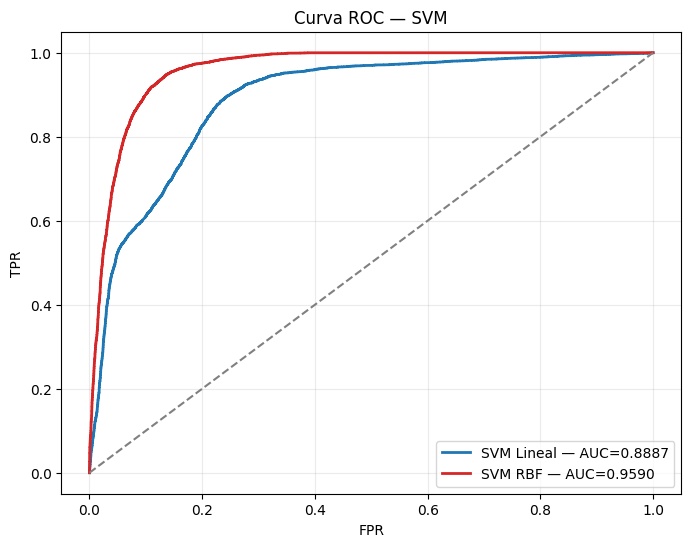

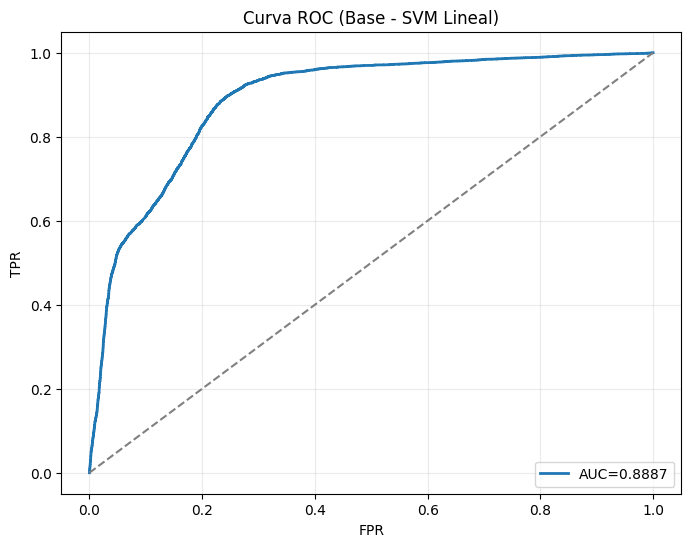

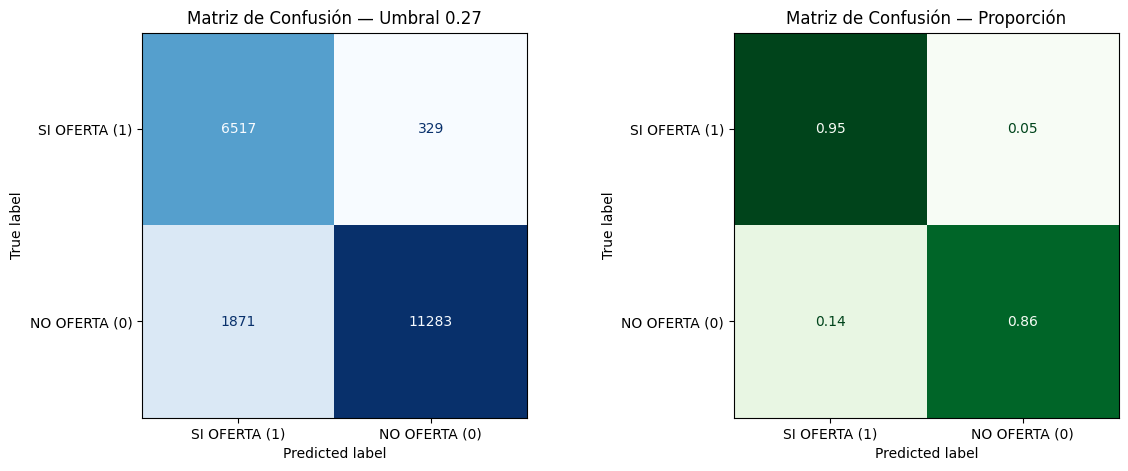

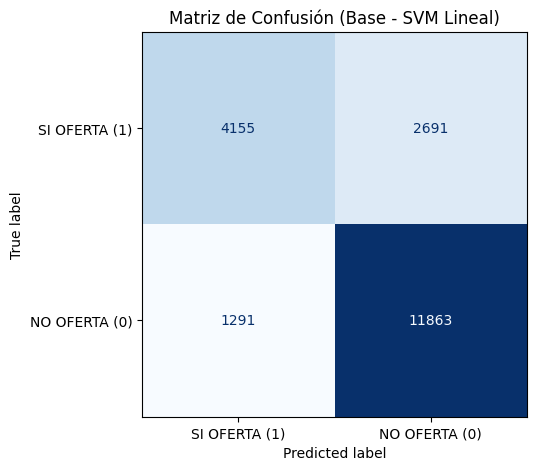

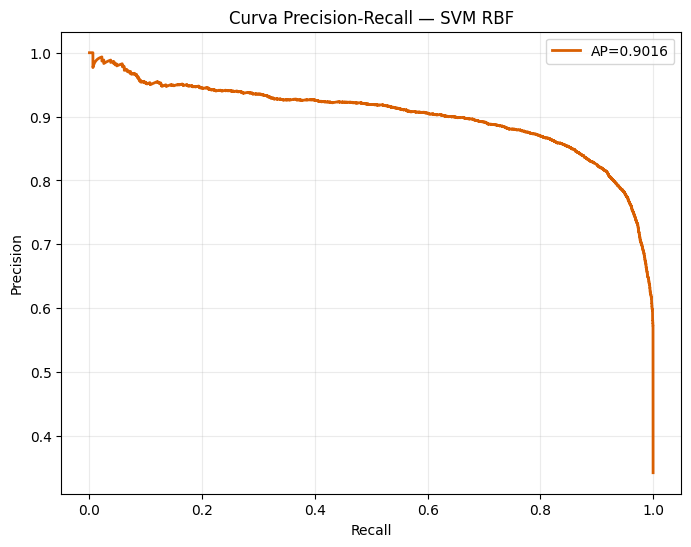

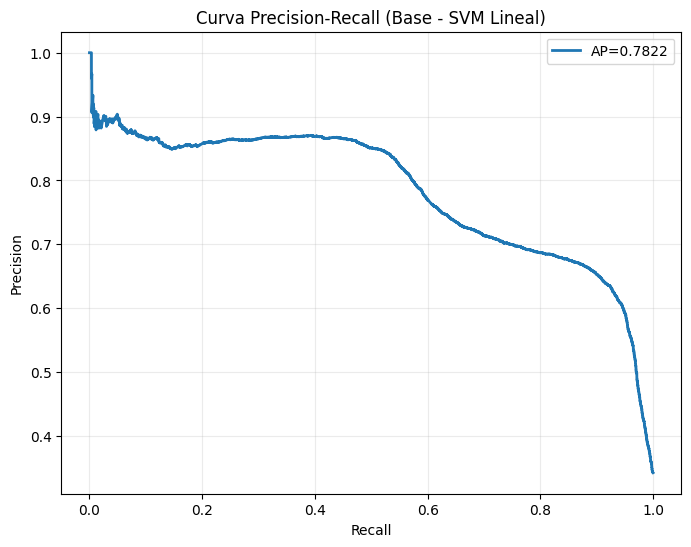

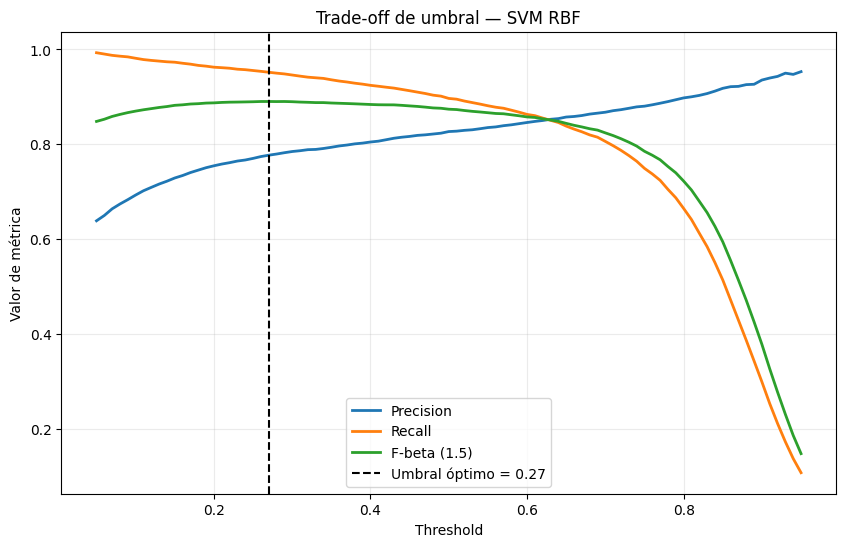

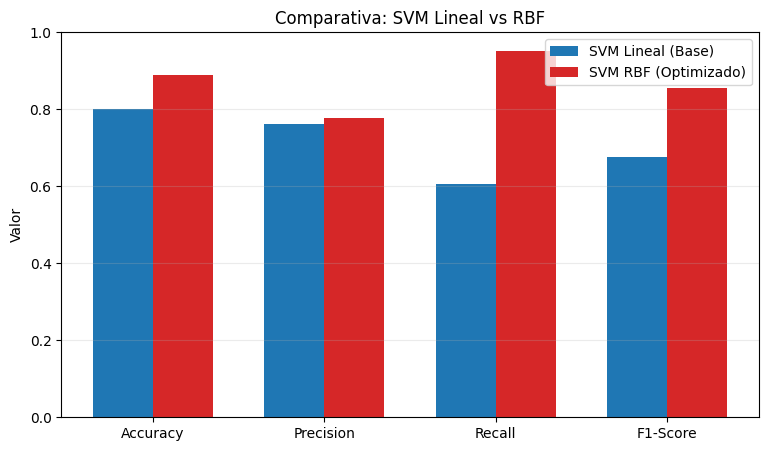

Summary JSON guardado: /Users/apple/mineria/datalake_gold/outputs_svm/informe/svm_offer_received_summary.json
Todos los artefactos SVM generados correctamente.


In [12]:
# --- Gráficas estándar ---
fpr_b, tpr_b, _ = roc_curve(y_test_p, base_proba)
fpr_i, tpr_i, _ = roc_curve(y_test_p, imp_proba)

# ROC comparativa
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_b, tpr_b, linewidth=2, label=f'SVM Lineal — AUC={base_metrics["ROC-AUC"]:.4f}')
ax.plot(fpr_i, tpr_i, linewidth=2, color="#d62728", label=f'SVM RBF — AUC={metrics_opt["ROC-AUC"]:.4f}')
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set(xlabel="FPR", ylabel="TPR", title="Curva ROC — SVM")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.25)
fig.savefig(IMG_DIR / "svm_roc_curve.png", dpi=160, bbox_inches="tight"); plt.show()

# ROC base
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_b, tpr_b, linewidth=2, color="#1f77b4", label=f'AUC={base_metrics["ROC-AUC"]:.4f}')
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set(xlabel="FPR", ylabel="TPR", title="Curva ROC (Base - SVM Lineal)")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.25)
fig.savefig(IMG_DIR / "svm_roc_curve_base.png", dpi=160, bbox_inches="tight"); plt.show()

# Confusion matrix optimized
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=["SI OFERTA (1)", "NO OFERTA (0)"]).plot(
    cmap="Blues", ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title(f"Matriz de Confusión — Umbral {best_t:.2f}")
cm_norm = cm_opt.astype(float) / cm_opt.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["SI OFERTA (1)", "NO OFERTA (0)"]).plot(
    cmap="Greens", ax=axes[1], values_format=".2f", colorbar=False)
axes[1].set_title("Matriz de Confusión — Proporción")
fig.savefig(IMG_DIR / "svm_confusion_matrix.png", dpi=160, bbox_inches="tight"); plt.show()

# Confusion matrix base
cm_b = confusion_matrix(y_test_p, base_pred, labels=[1, 0])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=["SI OFERTA (1)", "NO OFERTA (0)"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de Confusión (Base - SVM Lineal)")
fig.savefig(IMG_DIR / "svm_confusion_matrix_base.png", dpi=160, bbox_inches="tight"); plt.show()

# Precision-Recall improved
prec_i, rec_i, _ = precision_recall_curve(y_test_p, imp_proba)
ap_i = average_precision_score(y_test_p, imp_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_i, prec_i, linewidth=2, color="#d95f02", label=f"AP={ap_i:.4f}")
ax.set(xlabel="Recall", ylabel="Precision", title="Curva Precision-Recall — SVM RBF")
ax.legend(); ax.grid(True, alpha=0.25)
fig.savefig(IMG_DIR / "svm_precision_recall_curve.png", dpi=160, bbox_inches="tight"); plt.show()

# Precision-Recall base
prec_b, rec_b, _ = precision_recall_curve(y_test_p, base_proba)
ap_b = average_precision_score(y_test_p, base_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_b, prec_b, linewidth=2, color="#1f77b4", label=f"AP={ap_b:.4f}")
ax.set(xlabel="Recall", ylabel="Precision", title="Curva Precision-Recall (Base - SVM Lineal)")
ax.legend(); ax.grid(True, alpha=0.25)
fig.savefig(IMG_DIR / "svm_pr_base.png", dpi=160, bbox_inches="tight"); plt.show()

# Threshold tradeoff
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thr_df["threshold"], thr_df["precision"],  label="Precision",    linewidth=2)
ax.plot(thr_df["threshold"], thr_df["recall"],     label="Recall",       linewidth=2)
ax.plot(thr_df["threshold"], thr_df["f_beta_1_5"], label="F-beta (1.5)", linewidth=2)
ax.axvline(best_t, color="black", linestyle="--", label=f"Umbral óptimo = {best_t:.2f}")
ax.set(xlabel="Threshold", ylabel="Valor de métrica", title="Trade-off de umbral — SVM RBF")
ax.legend(); ax.grid(True, alpha=0.25)
fig.savefig(IMG_DIR / "svm_threshold_tradeoff.png", dpi=160, bbox_inches="tight"); plt.show()

# Comparativa modelos
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metric_names)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, [base_metrics[m] for m in metric_names], w, label="SVM Lineal (Base)",    color="#1f77b4")
ax.bar(x + w/2, [metrics_opt[m]  for m in metric_names], w, label="SVM RBF (Optimizado)", color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set(ylabel="Valor", title="Comparativa: SVM Lineal vs RBF"); ax.set_ylim(0, 1)
ax.legend(); ax.grid(axis="y", alpha=0.25)
fig.savefig(IMG_DIR / "svm_model_comparison.png", dpi=160, bbox_inches="tight"); plt.show()

# --- JSON Summary ---
SUMMARY_PATH = INF_DIR / "svm_offer_received_summary.json"

def make_jsonable(value):
    if isinstance(value, Path): return str(value)
    if isinstance(value, pd.DataFrame): return json.loads(value.to_json(orient="records", force_ascii=False))
    if isinstance(value, pd.Series):    return json.loads(value.to_json(force_ascii=False))
    if isinstance(value, dict):   return {str(k): make_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [make_jsonable(i) for i in value]
    if isinstance(value, np.generic): return value.item()
    return value

summary = {
    "model_name": "SVM_RBF",
    "target": TARGET,
    "best_threshold": best_t,
    "best_params": {"kernel": "rbf", "C": 10.0, "gamma": "scale"},
    "metrics": {
        "threshold_0_50": metrics_050,
        "threshold_optimized": metrics_opt,
    },
    "confusion_matrix": {"tp": int(tp), "fn": int(fn), "fp": int(fp), "tn": int(tn)},
    "threshold_preview": thr_df.sort_values("threshold").head(20),
}
with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(make_jsonable(summary), f, indent=2, ensure_ascii=False)
print(f"Summary JSON guardado: {SUMMARY_PATH}")
print("Todos los artefactos SVM generados correctamente.")